# Paper vs ghost nodes hourly evaluation

Notebook minimal pour comparer les checkpoints du papier avec les nouveaux checkpoints `ghost/source nodes`.

Le principe reste celui de `jupyter/eval_checkpoints_fixed_hourly.ipynb` :
- evaluation autoregressive sur des horizons horaires,
- meme structure `METHODS`,
- une seule cellule utilisateur pour choisir les methodes et les composantes a tracer.


In [5]:
from pathlib import Path
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

def find_project_root():
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "python").exists() and (candidate / "bin").exists():
            return candidate
    raise RuntimeError("Project root not found.")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from modulus.launch.utils import load_checkpoint
from python.CustomMeshGraphNet import MeshGraphNetWithSourceNodes
from python.create_dgl_dataset import (
    TelemacDataset,
    TelemacDatasetWithQ,
    TelemacDatasetWithSourceNodes,
)
from python.eval_rollout import (
    build_model as build_standard_rollout_model,
    build_rollout_context,
    create_rollout_state,
    denormalize_state,
    load_model_checkpoint as load_standard_checkpoint,
    rollout_step,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
# =====================
# Parametres utilisateur
# =====================
DT_SECONDS = 1800.0
REQUESTED_MAX_HOURS = 40
MAX_SEQUENCES = 205

NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

TEST_EVENTS = [
    "Group_1_peak_2600",
    "Group_2_peak_1000",
    "Group_2_peak_1200",
    "Group_2_peak_1600",
    "Group_4_peak_2000",
    "Group_1_peak_1200",
    "Group_1_peak_2400",
    "Group_3_peak_3400",
]

PAPER_DYNAMIC_ROOT = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8"
GHOST_DYNAMIC_ROOT = "/work/m24046/m24046mrcr/dataset_Tet_short_ghost/x8_short"
HYDRO_ROOT = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes"

def build_dynamic_files(root_dir):
    return [
        f"{root_dir}/{event_name}_{event_name}_0_35-64_interpolated.pkl"
        for event_name in TEST_EVENTS
    ]

def build_hydro_files(root_dir):
    return [
        f"{root_dir}/generated_hydrographs_{event_name}.liq"
        for event_name in TEST_EVENTS
    ]

PAPER_DYNAMIC_DIR = build_dynamic_files(PAPER_DYNAMIC_ROOT)
GHOST_DYNAMIC_DIR = build_dynamic_files(GHOST_DYNAMIC_ROOT)
HYDRO_DIR = build_hydro_files(HYDRO_ROOT)

METHODS = [
    {
        "name": "Experiment 1",
        "model_type": "standard",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience1/Seed0/",
        "epoch": 900,
        "use_q_feature": False,
        "data_dir": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin",
    },
    {
        "name": "Experiment 2",
        "model_type": "standard",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience7/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "data_dir": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin",
    },
    {
        "name": "Experiment 3",
        "model_type": "standard",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience9/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "data_dir": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin",
    },
    {
        "name": "Experiment 4",
        "model_type": "standard",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience2/Seed0/",
        "epoch": 900,
        "use_q_feature": False,
        "data_dir": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin",
    },
    {
        "name": "Experiment 5",
        "model_type": "standard",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience8/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "data_dir": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin",
    },
    {
        "name": "Experiment 6",
        "model_type": "standard",
        "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience10/Seed0/",
        "epoch": 900,
        "use_q_feature": True,
        "data_dir": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin",
    },
    {
        "name": "Ghost x8",
        "model_type": "source_nodes",
        "ckpt_dir": "/work/m24046/m24046mrcr/Test_Tet_ghost/checkpoints/config_multimesh_Tet_ghost/Seed0/",
        "epoch": 900,
        "data_dir": "/work/m24046/m24046mrcr/dataset_Tet_short_ghost/x8_short/Mesh8_base.bin",
        "dynamic_dir": GHOST_DYNAMIC_DIR,
        "hydro_dir": HYDRO_DIR,
        "inlet_node_lists": [[12770]],
    },
    {
        "name": "Ghost multimesh",
        "model_type": "source_nodes",
        "ckpt_dir": "/work/m24046/m24046mrcr/Test_Tet_ghost/checkpoints/config_multimesh_Tet_ghost_mm32/Seed0/",
        "epoch": 1890,
        "data_dir": "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Multimesh_8_32.bin",
        "dynamic_dir": GHOST_DYNAMIC_DIR,
        "hydro_dir": HYDRO_DIR,
        "inlet_node_lists": [[12770]],
    },
]

RUNS = {method["name"]: f"{method['name']}@{method['epoch']}" for method in METHODS}

METHOD_COLORS = {
    "Experiment 1": "#1f77b4",
    "Experiment 2": "#ff7f0e",
    "Experiment 3": "#2ca02c",
    "Experiment 4": "#d62728",
    "Experiment 5": "#9467bd",
    "Experiment 6": "#8c564b",
    "Ghost x8": "#e377c2",
    "Ghost multimesh": "#17becf",
}

PLOT_METHOD_NAMES = ["Experiment 6","Experiment 4", "Ghost x8", "Ghost multimesh"]
PLOT_COMPONENTS = ["h", "u", "v"]
PLOT_TITLE = "Paper vs ghost nodes"


In [7]:
def get_dynamic_length(file_path):
    with open(file_path, "rb") as f:
        return len(pickle.load(f))

all_dynamic_files = []
for method in METHODS:
    all_dynamic_files.extend(method.get("dynamic_dir", PAPER_DYNAMIC_DIR))

dynamic_lengths = [get_dynamic_length(path) for path in sorted(set(all_dynamic_files))]
min_num_samples = min(dynamic_lengths)
hour_in_steps = max(1, int(round(3600.0 / DT_SECONDS)))
max_available_step = max(1, min_num_samples - 1)
available_max_hours = max_available_step // hour_in_steps

if available_max_hours < 1:
    raise ValueError("Aucun horizon horaire disponible avec les fichiers dynamiques courants.")

if available_max_hours < REQUESTED_MAX_HOURS:
    print(
        f"Attention: au moins un fichier test ne contient que {min_num_samples} echantillons. "
        f"Le notebook evaluera donc {available_max_hours} heures au lieu de {REQUESTED_MAX_HOURS}."
    )

MAX_HOURS = available_max_hours
HORIZONS_STEPS = [h * hour_in_steps for h in range(1, MAX_HOURS + 1)]
print(
    f"min_num_samples={min_num_samples} | MAX_HOURS={MAX_HOURS} | "
    f"max_horizon_step={HORIZONS_STEPS[-1]}"
)


Attention: au moins un fichier test ne contient que 30 echantillons. Le notebook evaluera donc 14 heures au lieu de 40.
min_num_samples=30 | MAX_HOURS=14 | max_horizon_step=28


In [8]:
# =====================
# Evaluation
# =====================
def build_dataset(method, sequence_length, split="test", overlap=1):
    dynamic_files = method.get("dynamic_dir", PAPER_DYNAMIC_DIR)
    hydro_files = method.get("hydro_dir", HYDRO_DIR)
    model_type = method["model_type"]

    if model_type == "source_nodes":
        return TelemacDatasetWithSourceNodes(
            name=f"eval_{split}_source_nodes",
            data_dir=method["data_dir"],
            dynamic_data_files=dynamic_files,
            hydro_data_files=hydro_files,
            inlet_node_lists=method["inlet_node_lists"],
            use_q_feature=method.get("use_q_feature", False),
            split=split,
            ckpt_path=method["ckpt_dir"],
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )

    if method.get("use_q_feature", False):
        return TelemacDatasetWithQ(
            name=f"eval_{split}_q",
            data_dir=method["data_dir"],
            dynamic_data_files=dynamic_files,
            hydro_data_files=hydro_files,
            split=split,
            ckpt_path=method["ckpt_dir"],
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )

    return TelemacDataset(
        name=f"eval_{split}",
        data_dir=method["data_dir"],
        dynamic_data_files=dynamic_files,
        split=split,
        ckpt_path=method["ckpt_dir"],
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )

def build_standard_model_for_method(ds, method):
    num_input_features = ds.base_graph.ndata["static"].shape[1] + (4 if method.get("use_q_feature", False) else 3)
    model = build_standard_rollout_model(
        num_input_features=num_input_features,
        num_edge_features=NUM_EDGE_FEATURES,
        num_output_features=NUM_OUTPUT_FEATURES,
        mp_layers=MP_LAYERS,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )
    return load_standard_checkpoint(model, method["ckpt_dir"], method["epoch"], device=device)

def build_source_model_for_method(ds, method):
    model = MeshGraphNetWithSourceNodes(
        input_dim_nodes_phys=ds.base_graph.ndata["static"].shape[1] + ds.physical_dynamic_dim,
        input_dim_nodes_src=len(ds.source_feature_names),
        input_dim_edges=NUM_EDGE_FEATURES,
        output_dim=NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )
    load_checkpoint(method["ckpt_dir"], models=model, device=device, epoch=method["epoch"])
    model.to(device)
    model.eval()
    return model

def summarize_l1(agg, horizons_steps):
    summary = {}
    for step in horizons_steps:
        if len(agg[step]) == 0:
            continue
        l1_stack = np.stack(agg[step], axis=0)
        summary[step] = {
            "l1_mean": np.nanmean(l1_stack, axis=0).tolist(),
            "l1_std": np.nanstd(l1_stack, axis=0).tolist(),
        }
    return summary

def build_source_context(ds):
    stats = ds.node_stats
    return {
        "static_dim": ds.base_graph.ndata["static"].shape[1],
        "physical_dynamic_dim": ds.physical_dynamic_dim,
        "state_mean": torch.tensor(
            [stats["h"].item(), stats["u"].item(), stats["v"].item()],
            dtype=torch.float32,
            device=device,
        ),
        "state_std": torch.tensor(
            [stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()],
            dtype=torch.float32,
            device=device,
        ),
        "delta_mean": torch.tensor(
            [stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()],
            dtype=torch.float32,
            device=device,
        ),
        "delta_std": torch.tensor(
            [stats["delta_h_std"].item(), stats["delta_u_std"].item(), stats["delta_v_std"].item()],
            dtype=torch.float32,
            device=device,
        ),
    }

def source_denormalize_state(xn, context):
    return xn * context["state_std"] + context["state_mean"]

def source_denormalize_delta(yn, context):
    return yn * context["delta_std"] + context["delta_mean"]

def source_renormalize_state(x, context):
    return (x - context["state_mean"]) / (context["state_std"] + 1e-12)

def source_h_mask(x_phys):
    onehot = x_phys[:, :4]
    target = torch.tensor([0, 1, 0, 0], device=onehot.device)
    return (onehot == target).all(dim=1)

def evaluate_standard_model(model, ds, method, horizons_steps, max_sequences):
    rollout_context = build_rollout_context(ds, device=device, use_q_feature=method.get("use_q_feature", False))
    agg = {step: [] for step in horizons_steps}
    step_set = set(horizons_steps)
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        rollout_state = create_rollout_state(graphs[0], rollout_context)

        for t in range(max_h):
            x_gt_full_n = graphs[t + 1].ndata["x"][:, rollout_context.dyn_start:rollout_context.dyn_start + rollout_context.dyn_len].to(device)
            x_gt = denormalize_state(x_gt_full_n[:, :3], rollout_context)
            q_t1_n = x_gt_full_n[:, 3:4] if method.get("use_q_feature", False) else None

            step_result = rollout_step(
                model,
                rollout_state,
                rollout_context,
                x_gt=x_gt,
                q_t1_n=q_t1_n,
            )

            step = t + 1
            if step in step_set:
                l1 = torch.mean(torch.abs(step_result.predicted_state - step_result.target_state), dim=0)
                agg[step].append(l1.detach().cpu().numpy())

            rollout_state = step_result.next_state

    return summarize_l1(agg, horizons_steps)

def evaluate_source_model(model, ds, horizons_steps, max_sequences):
    context = build_source_context(ds)
    agg = {step: [] for step in horizons_steps}
    step_set = set(horizons_steps)
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        sequence = ds[idx]
        if len(sequence) <= max_h:
            continue

        state = {
            "graph": sequence[0]["graph"].to(device),
            "x_phys": sequence[0]["x_phys"].to(device),
            "x_src": sequence[0]["x_src"].to(device),
        }

        for t in range(max_h):
            next_step = sequence[t + 1]
            edge_features = state["graph"].edata["x"].to(device)

            with torch.no_grad():
                y_pred_n = model(
                    graph=state["graph"],
                    x_phys=state["x_phys"],
                    x_src=state["x_src"],
                    edge_features=edge_features,
                )

            xn_t = state["x_phys"][:, context["static_dim"]:context["static_dim"] + 3]
            x_t = source_denormalize_state(xn_t, context)
            y_pred = source_denormalize_delta(y_pred_n, context)
            x_t1_pred = x_t + y_pred

            xn_t1_gt = next_step["x_phys"][:, context["static_dim"]:context["static_dim"] + 3].to(device)
            x_t1_gt = source_denormalize_state(xn_t1_gt, context)

            mask_h = source_h_mask(state["x_phys"])
            x_t1_pred = x_t1_pred.clone()
            x_t1_pred[mask_h, 0] = x_t1_gt[mask_h, 0]

            step = t + 1
            if step in step_set:
                l1 = torch.mean(torch.abs(x_t1_pred - x_t1_gt), dim=0)
                agg[step].append(l1.detach().cpu().numpy())

            xn_t1_next = source_renormalize_state(x_t1_pred, context)
            static_features = state["x_phys"][:, :context["static_dim"]]
            forcing_t1 = next_step["x_phys"][
                :,
                context["static_dim"] + 3:context["static_dim"] + context["physical_dynamic_dim"],
            ].to(device)
            state = {
                "graph": next_step["graph"].to(device),
                "x_phys": torch.cat((static_features, xn_t1_next, forcing_t1), dim=1),
                "x_src": next_step["x_src"].to(device),
            }

    return summarize_l1(agg, horizons_steps)

def evaluate_single_checkpoint(method, horizons_steps, max_sequences):
    sequence_length = max(horizons_steps) + 1
    ds = build_dataset(method, sequence_length=sequence_length, split="test", overlap=1)

    if len(ds) == 0:
        raise ValueError(
            f"Aucune sequence disponible pour sequence_length={sequence_length}. "
            "Reduis REQUESTED_MAX_HOURS ou utilise des fichiers plus longs."
        )

    if method["model_type"] == "source_nodes":
        model = build_source_model_for_method(ds, method)
        return evaluate_source_model(model, ds, horizons_steps, max_sequences)

    model = build_standard_model_for_method(ds, method)
    return evaluate_standard_model(model, ds, method, horizons_steps, max_sequences)

def evaluate_fixed_methods(methods, horizons_steps, max_sequences):
    evaluations = {}
    for method in methods:
        run_name = RUNS[method["name"]]
        print(f"Evaluating {run_name}")
        evaluations[run_name] = evaluate_single_checkpoint(
            method,
            horizons_steps=horizons_steps,
            max_sequences=max_sequences,
        )
    return evaluations


In [9]:
# =====================
# Lancement de l'evaluation
# =====================
evaluations = evaluate_fixed_methods(
    METHODS,
    horizons_steps=HORIZONS_STEPS,
    max_sequences=MAX_SEQUENCES,
)

sorted(evaluations)


Evaluating Experiment 1@900
Loading normalization statistics...


[13:35:36 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience1/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[13:35:36 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience1/Seed0/checkpoint.0.900.pt to device cuda


Evaluating Experiment 2@900
Loading normalization statistics...


[13:35:43 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience7/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[13:35:43 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience7/Seed0/checkpoint.0.900.pt to device cuda


Evaluating Experiment 3@900
Loading normalization statistics...


...

Evaluating Ghost x8@900
Loading normalization statistics...


[13:36:02 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Tet_ghost/checkpoints/config_multimesh_Tet_ghost/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[13:36:02 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Tet_ghost/checkpoints/config_multimesh_Tet_ghost/Seed0/checkpoint.0.900.pt to device cuda


Evaluating Ghost multimesh@1890
Loading normalization statistics...


[13:36:07 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Tet_ghost/checkpoints/config_multimesh_Tet_ghost_mm32/Seed0/MeshGraphNet.0.1890.mdlus to device cuda
[13:36:07 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Tet_ghost/checkpoints/config_multimesh_Tet_ghost_mm32/Seed0/checkpoint.0.1890.pt to device cuda


['Experiment 1@900',
 'Experiment 2@900',
 'Experiment 3@900',
 'Experiment 4@900',
 'Experiment 5@900',
 'Experiment 6@900',
 'Ghost multimesh@1890',
 'Ghost x8@900']

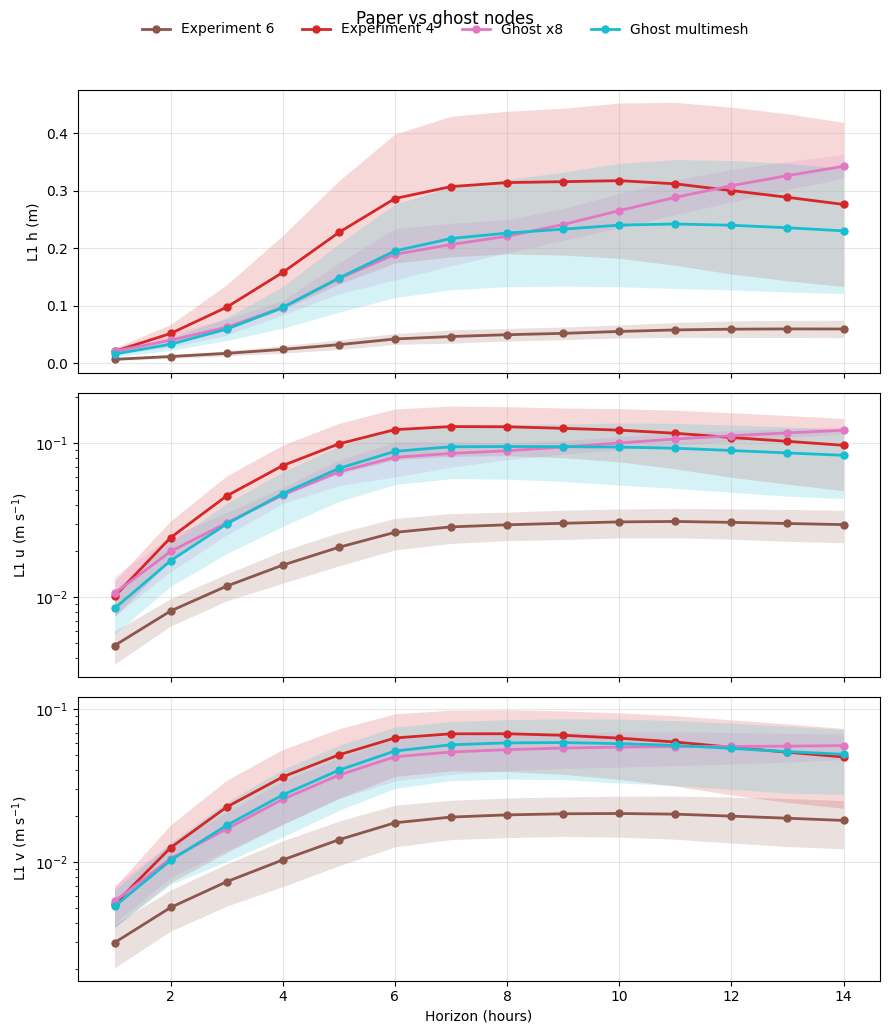

In [10]:
# =====================
# Plot
# =====================
COMPONENT_INDEX = {"h": 0, "u": 1, "v": 2}
COMPONENT_LABEL = {
    "h": "L1 h (m)",
    "u": r"L1 u (m s$^{-1}$)",
    "v": r"L1 v (m s$^{-1}$)",
}

def style_for_method(name):
    return {
        "color": METHOD_COLORS[name],
        "marker": "o",
        "linewidth": 2,
        "markersize": 5,
    }

def extract_l1_mean_std(evaluations, run_name, horizons_steps, component_name):
    component_index = COMPONENT_INDEX[component_name]
    summary = evaluations[run_name]
    mean_values = np.array(
        [summary.get(step, {}).get("l1_mean", [np.nan, np.nan, np.nan])[component_index] for step in horizons_steps],
        dtype=float,
    )
    std_values = np.array(
        [summary.get(step, {}).get("l1_std", [np.nan, np.nan, np.nan])[component_index] for step in horizons_steps],
        dtype=float,
    )
    return mean_values, std_values

def plot_selected_methods(evaluations, method_names, horizons_steps, component_names, title=None):
    missing = [name for name in method_names if name not in RUNS]
    if missing:
        raise ValueError(f"Unknown methods: {missing}")

    components = [name.lower() for name in component_names]
    invalid_components = [name for name in components if name not in COMPONENT_INDEX]
    if invalid_components:
        raise ValueError(f"Unknown components: {invalid_components}")

    hours = np.array([step * DT_SECONDS / 3600.0 for step in horizons_steps], dtype=float)
    fig, axes = plt.subplots(len(components), 1, figsize=(9, 3.5 * len(components)), sharex=True)
    if len(components) == 1:
        axes = [axes]

    for ax, component_name in zip(axes, components):
        use_log = component_name in {"u", "v"}
        for method_name in method_names:
            run_name = RUNS[method_name]
            mean_values, std_values = extract_l1_mean_std(evaluations, run_name, horizons_steps, component_name)
            lower = mean_values - std_values
            upper = mean_values + std_values

            if use_log:
                mean_values = mean_values.copy()
                lower = lower.copy()
                upper = upper.copy()
                mean_values[mean_values <= 0.0] = np.nan
                lower[lower <= 0.0] = np.nan
                upper[upper <= 0.0] = np.nan

            style = style_for_method(method_name)
            ax.plot(hours, mean_values, label=method_name, **style)
            ax.fill_between(hours, lower, upper, color=style["color"], alpha=0.18, linewidth=0)

        ax.set_ylabel(COMPONENT_LABEL[component_name])
        if use_log:
            ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Horizon (hours)")
    handles, labels = axes[0].get_legend_handles_labels()
    if title:
        fig.suptitle(title)
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=min(4, len(labels)), frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=min(4, len(labels)), frameon=False)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_selected_methods(
    evaluations=evaluations,
    method_names=PLOT_METHOD_NAMES,
    horizons_steps=HORIZONS_STEPS,
    component_names=PLOT_COMPONENTS,
    title=PLOT_TITLE,
)
